#Граф цитирований vs. граф соавторства в лингвистике

In [63]:
import requests, json, time, math, re

import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm

from transliterate import translit
from rapidfuzz import fuzz
from collections import defaultdict

from networkx.algorithms.community import girvan_newman, asyn_lpa_communities
from itertools import islice
import matplotlib.patches as mpatches

from sklearn.neighbors import KDTree
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import numpy as np

#1.Извлечение данных

In [64]:
'''
# Беру три относительно общедисциплинарных и известных журнала по лингвистике
journals = {
    "Вопросы языкознания": "0373-658X",
    "Русская речь": "0131-6117",
    "Русский язык в научном освещении": "1681-1062",
}
# Ищу на openalex; проверяю, есть ли они вообще
for name, issn in journals.items():
    r = requests.get(f"https://api.openalex.org/sources?filter=issn:{issn}")
    data = r.json()
    if data["results"]:
        src = data["results"][0]
        print(f"{name}: id={src['id']}, works_count={src['works_count']}")
    else:
        print(f"{name}: НЕ НАЙДЕН")
'''

'\n# Беру три относительно общедисциплинарных и известных журнала по лингвистике\njournals = {\n    "Вопросы языкознания": "0373-658X",\n    "Русская речь": "0131-6117",\n    "Русский язык в научном освещении": "1681-1062",\n}\n# Ищу на openalex; проверяю, есть ли они вообще\nfor name, issn in journals.items():\n    r = requests.get(f"https://api.openalex.org/sources?filter=issn:{issn}")\n    data = r.json()\n    if data["results"]:\n        src = data["results"][0]\n        print(f"{name}: id={src[\'id\']}, works_count={src[\'works_count\']}")\n    else:\n        print(f"{name}: НЕ НАЙДЕН")\n'

In [65]:
journals = {
    "Вопросы языкознания": "0373-658X",
    "Русская речь": "0131-6117",
    "Русский язык в научном освещении": "1681-1062",
}
#Извлекаю статьи с метаданными
def fetch_works_by_issn(issn, journal_name, year_from=2010, year_to=2024):
    all_works = []
    cursor = "*"
    while cursor:
        url = (
            f"https://api.openalex.org/works"
            f"?filter=primary_location.source.issn:{issn},"
            f"publication_year:{year_from}-{year_to}"
            f"&per_page=200&cursor={cursor}"
            f"&select=id,doi,title,publication_year,authorships,"
            f"cited_by_count,referenced_works"
        )
        r = requests.get(url, headers={"User-Agent": "mailto:your@email.com"})
        data = r.json()
        works = data.get("results", [])
        all_works.extend(works)
        print(f"  {journal_name}: {len(all_works)} статей...")
        cursor = data.get("meta", {}).get("next_cursor")
        time.sleep(0.3)
    return all_works

results = {}
for name, issn in journals.items():
    results[name] = fetch_works_by_issn(issn, name)

with open("openalex_raw.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
# Итого у нас примерно полтора тысячи статей. Есть с чем работать.

  Вопросы языкознания: 200 статей...
  Вопросы языкознания: 400 статей...
  Вопросы языкознания: 600 статей...
  Вопросы языкознания: 609 статей...
  Русская речь: 200 статей...
  Русская речь: 400 статей...
  Русская речь: 405 статей...
  Русский язык в научном освещении: 200 статей...
  Русский язык в научном освещении: 252 статей...


#2.Построение графов

(Предварительно вручную фильтрую имена в json'е со статьями: многие оформлены в разнобой, с разным порядком ФИО, на латинице и кириллице)

Граф соавторства

In [66]:
!pip install transliterate rapidfuzz -q

Смёрджено дублей: 323


100%|██████████| 1266/1266 [00:00<00:00, 187387.12it/s]


Граф соавторства:
  Вершин (авторов): 13
  Рёбер (совместных работ): 14


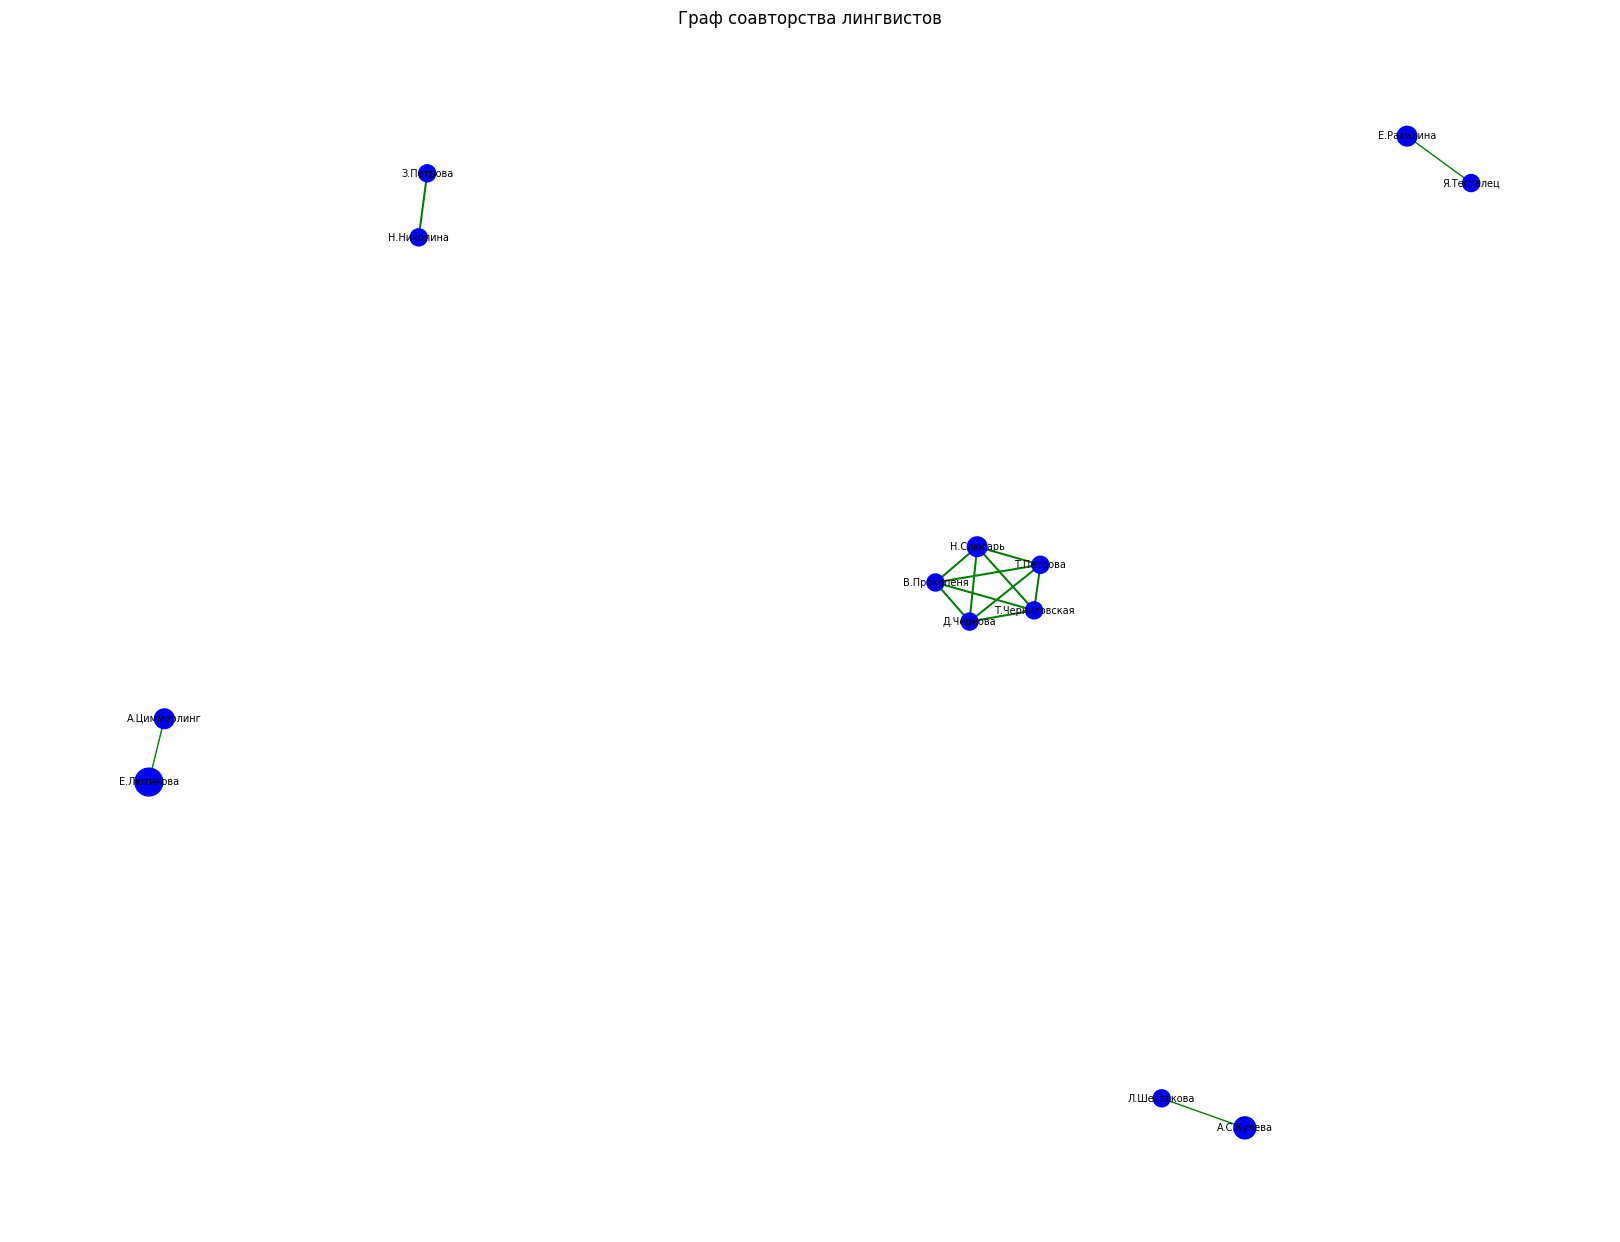

In [67]:
# openalex_clean.json -- новый отфильтрованный JSON с данными
with open("openalex_clean.json", encoding="utf-8") as f:
    raw = json.load(f)
'''
Перед фильтрацией пытался всем чем угодно унифицировать бардак в метаданных, а именно в фамилиях.
Получилось плохо, если честно, в силу того, что транслитератором и рэпидфьюзером я овладел пару часов назад,
но для истории (и чтобы код не взорвался) я оставил эту часть.
'''
def normalize_name(name):
    try:
        name = translit(name, 'ru', reversed=True)
    except Exception:
        pass
    name = name.lower()
    name = re.sub(r"[.\'\`ʹ]", '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

def get_last_name(name):
    # Берём самое длинное слово — почти всегда фамилия, а не инициал
    parts = normalize_name(name).split()
    return max(parts, key=len) if parts else name

# Группируем всех авторов с одинаковой нормализованной фамилией в один canonical.
# Canonical = первый встреченный в группе.
by_lastname = defaultdict(list)
for aid, name in author_names.items():
    by_lastname[get_last_name(name)].append((aid, name))

id_to_canonical = {}
for lastname, group in by_lastname.items():
    # Первый в группе становится canonical для всех остальных
    canonical_id = group[0][0]
    for aid, name in group:
        id_to_canonical[aid] = canonical_id

# Предпочитаем латинское написание имени как каноническое
has_cyr = lambda s: any('а' <= c <= 'я' or 'А' <= c <= 'Я' for c in s)
for old_id, can_id in id_to_canonical.items():
    if old_id != can_id:
        old_name = author_names.get(old_id, "")
        can_name = author_names.get(can_id, "")
        if has_cyr(can_name) and not has_cyr(old_name):
            author_names[can_id] = old_name

def canonicalize(aid):
    return id_to_canonical.get(aid, aid)

work_to_authors_c = {
    wid: list(set(canonicalize(a) for a in aids))
    for wid, aids in work_to_authors.items()
}

print(f"Смёрджено дублей: {sum(1 for k, v in id_to_canonical.items() if k != v)}")

# Возвращаемся к графу

all_works = []
for journal_name, works in raw.items():
    for w in works:
        w["journal"] = journal_name
    all_works.extend(works)

# Храним все упоминавшиеся имена (по id автора)
author_counts = {}   # author_counts[id] -- кол-во статей
author_names  = {}   # author_names[id]  = display_name (для меток)
# ...и связи между авторами храним
coauthors = {}       # где coauthors[id_A][id_B] -- кол-во совместных статей

for work in tqdm(all_works):
    # Извлекаем список авторов текущей статьи.
    # Фильтруем организации: у них author.id = None (иначе шабаш в графе полный).
    ids_in_work = []
    for a in work.get("authorships", []):
        aid  = a.get("author", {}).get("id")
        name = a.get("author", {}).get("display_name")
        if aid and name:
            ids_in_work.append(aid)
            author_names[aid] = name # запоминаем имя для меток

    # Один автор может (и скорее всего будет) упоминаться несколько раз, потому строим список с единственными упоминаниями.
    unique_ids = list(set(ids_in_work))

    # Обновляем счётчик статей для каждого автора.
    for aid in unique_ids:
        author_counts[aid] = author_counts.get(aid, 0) + 1

    # Связи между авторами
    for aid in unique_ids:
        pers = coauthors.get(aid, {})
        for aid2 in unique_ids:
            if aid != aid2:
                pers[aid2] = pers.get(aid2, 0) + 1
        coauthors[aid] = pers

# Фильтрация: берём более-менее активных авторов. Тех, кто опубликовал хотя бы 3 статьи.
MIN_PAPERS = 3
active = {aid for aid, cnt in author_counts.items() if cnt >= MIN_PAPERS}

# Отслеживаем только активных авторов.
coauthors_f = {
    aid: {aid2: w for aid2, w in conn.items() if aid2 in active}
    for aid, conn in coauthors.items() if aid in active
}

# Функция для создания графа.
def form_coauthorship_graph(persons):
    G = nx.Graph()
    for n in persons.keys():
        for n2 in persons[n].keys():
            if not G.has_edge(n, n2):
                G.add_edge(n, n2)
    return G

G_coauth = form_coauthorship_graph(coauthors_f)

print(f"\nГраф соавторства:")
print(f"  Вершин (авторов): {G_coauth.number_of_nodes()}")
print(f"  Рёбер (совместных работ): {G_coauth.number_of_edges()}")

# Визуализация (в это, наверное, можно не вникать, ибо по большей части скопировано с интернета)
def draw_coauthorship_graph(G, persons, freqs, names, colors='b', layout='spring'):
    plt.figure(figsize=(16, 12))
    if layout == 'kawai':
        pstn = nx.kamada_kawai_layout(G)
    elif layout == 'circle':
        pstn = nx.drawing.layout.circular_layout(G)
    elif layout == 'random':
        pstn = nx.drawing.layout.random_layout(G)
    else:
        pstn = nx.spring_layout(G, seed=42)
    sz = [freqs[n] * 50 for n in G.nodes]
    lw = [math.log(persons[e[0]][e[1]], 10) + 1 for e in G.edges]
    labels = {n: names.get(n, n) for n in G.nodes}

    # Рисуем, собственно.
    nx.draw(G,
            pos=pstn,
            node_color=colors,
            edge_color='g',
            with_labels=True,
            labels=labels,
            node_size=sz,
            width=lw,
            font_size=7)
    plt.title("Граф соавторства лингвистов")

draw_coauthorship_graph(G_coauth, coauthors_f, author_counts, author_names)

Граф цитирования

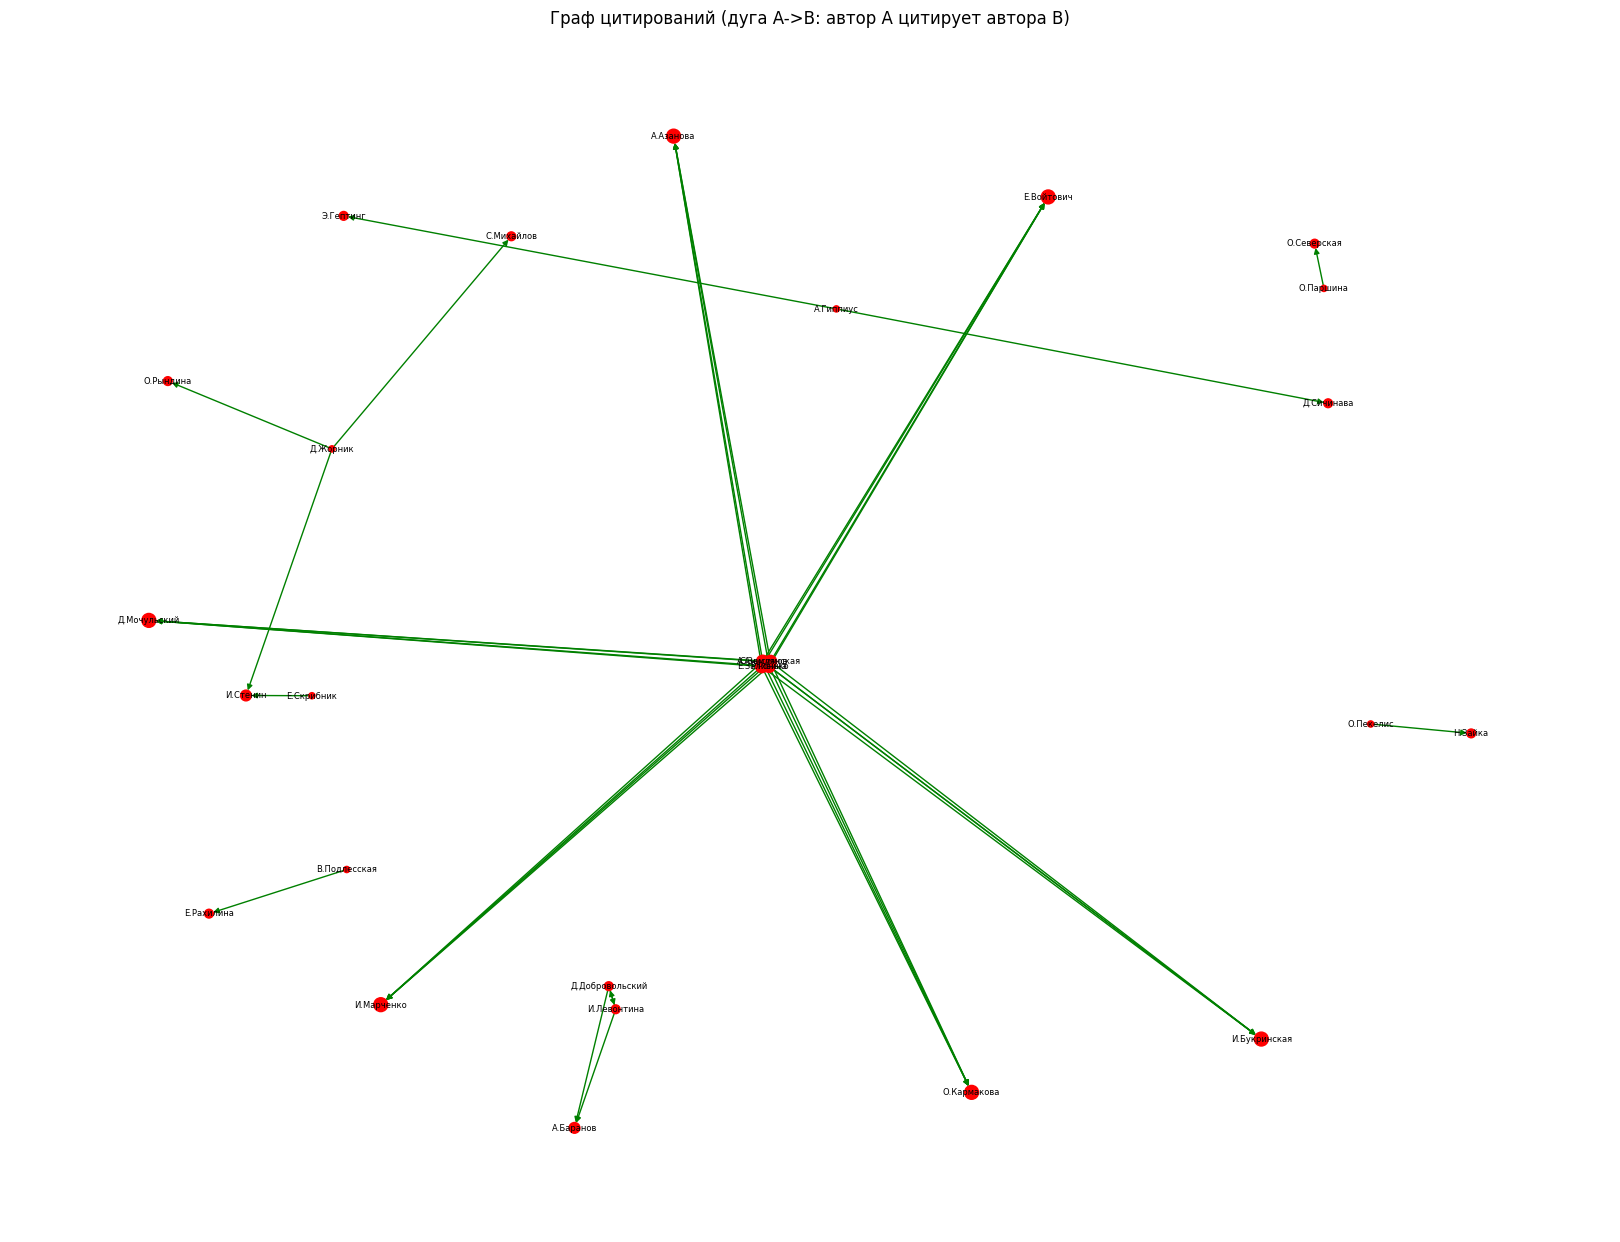

In [68]:
with open("openalex_clean.json", encoding="utf-8") as f:
    raw = json.load(f)

# Вершины -- авторы, дуга A->B = автор A написал статью, которая цитирует статью автора B.
citations = {}
for work in all_works:
    src_authors = work_to_authors_c.get(work["id"], [])
    if not src_authors:
        continue
    for ref_id in work.get("referenced_works", []):
        # Пропускаем внешние статьи, берём только выборку
        if ref_id not in work_ids:
            continue
        tgt_authors = work_to_authors_c.get(ref_id, [])
        # связи между авторами источника и авторами цитируемой статьи.
        for src_a in src_authors:
            conn = citations.get(src_a, {})
            for tgt_a in tgt_authors:
                if src_a != tgt_a: # не считаем самоцитирование!
                    conn[tgt_a] = conn.get(tgt_a, 0) + 1
            citations[src_a] = conn

# Функция для создания графа
def form_citation_graph(citations_dict):
    G = nx.DiGraph()
    # Перебираем все найденные авторы-источники.
    for src_a, targets in citations_dict.items():
        for tgt_a, weight in targets.items():
            # Вес -- количество раз, когда автор A цитировал автора B.
            G.add_edge(src_a, tgt_a, weight=weight)
    return G

G_cit = form_citation_graph(citations)

# Различаем полустепень захода (in-degree) и полустепень исхода (out-degree).
in_degrees = dict(G_cit.in_degree())
'''Проверка
print(f"Вершин: {G_cit.number_of_nodes()}, Дуг: {G_cit.number_of_edges()}")
print("\nВсе вершины:")
for node in G_cit.nodes:
    print(" ", author_names.get(node, node))
'''

# Визуализация (тоже можно не вникать, я сам плохо понимаю этот синтаксис)
def draw_citation_graph(G, names, in_deg, layout='spring'):
    plt.figure(figsize=(16, 12))
    if layout == 'kawai':
        pstn = nx.kamada_kawai_layout(G)
    else:
        pstn = nx.spring_layout(G, seed=42)
    sz = [in_deg.get(n, 0) * 20 + 20 for n in G.nodes]
    labels = {n: names.get(n, n) for n in G.nodes}
    # Рисуем граф.
    nx.draw(G,
            pos=pstn,
            node_color='r',
            edge_color='g',
            with_labels=True,
            labels=labels,
            node_size=sz,
            arrows=True,
            arrowsize=8,
            font_size=6)
    plt.title("Граф цитирований (дуга A->B: автор A цитирует автора B)")

draw_citation_graph(G_cit, author_names, in_degrees)

#3.Метрики для последующей группировки

In [69]:
# G_coauth — nx.Graph -> Girvan-Newman
# G_cit    — nx.DiGraph -> Label Propagation

#Граф соавторов: Girvan-Newman (во многом формально, потому что в этом графе уже чётко видны острова и сообщества)
community_map_coauth = {}
comm_id = 0

components = sorted(nx.connected_components(G_coauth), key=len, reverse=True)

for comp in components:
    subg = G_coauth.subgraph(comp).copy()
    if subg.number_of_nodes() >= 4 and subg.number_of_edges() > 0:
        gn = girvan_newman(subg)
        first_split = next(gn)
        for part in first_split:
            for node in part:
                community_map_coauth[node] = comm_id
            comm_id += 1
    else:
        for node in comp:
            community_map_coauth[node] = comm_id
        comm_id += 1

# Граф цитирований: Label Propagation (с приблудой в виде asyn позволяет брать ориентированные графы. Да и просто симпатяга)
community_map_cit = {}
communities_cit = list(asyn_lpa_communities(G_cit, weight='weight', seed=42))
for cid, community in enumerate(communities_cit):
    for node in community:
        community_map_cit[node] = cid

#4. Извлечение ключевых слов

In [70]:

# Запускаем отдельно для каждого из двух графов

# Всякий мусор, который почему-то плохо выкидывается сортировками
custom_stopwords = [
    "russian", "russia", "moscow", "oxford", "cambridge", "english",
    "german", "french", "european", "american", "chinese",
    "study", "studies", "analysis", "approach", "based", "using",
    "new", "case", "data", "review", "paper", "research",
    "introduction", "toward", "towards", "note", "notes",
    "language", "linguistic", "linguistics", "text", "texts",
    "word", "words", "grammar", "university", "že", 'eds', '368',
    '978', '2018', 'gt', 'lt', 'speech', 'sh', "press", 'isbn', 'tak', 'yu', '2015'
]
all_stopwords = list(ENGLISH_STOP_WORDS) + custom_stopwords

# Можно было бы взять BallTree, но у каждого графа не больше 20 групп, а при малой размерности KD-Tree работает лучше.
def extract_keywords_kdtree(community_map, all_works, label=""):
# Для заданного community_map строит KDTree и выводит ключевые слова.
    comm_texts = defaultdict(list)

    for work in all_works:
        title = work.get("title", "") or ""
        if not title.strip():
            continue
        for a in work.get("authorships", []):
            aid = a.get("author", {}).get("id")
            if aid and aid in community_map:
                comm_texts[community_map[aid]].append(title)
                break

    comm_ids = sorted(comm_texts.keys())
    corpus   = [" ".join(comm_texts[c]) for c in comm_ids]

    if len(comm_ids) < 2:
        print(f"{label}: недостаточно сообществ для KDTree")
        return {}

    vec = TfidfVectorizer(stop_words=all_stopwords, max_features=300, min_df=1, max_df=0.7) # max_df -- если слово присутствует в 70 и более процентах текстов -- считаем его за спам.
    X = vec.fit_transform(corpus).toarray().astype(float)

    tree = KDTree(X)

    k_neighbors = min(len(comm_ids), max(4, len(comm_ids) // 3)) #Стараюсь брать треть от группы, чтобы больше учитывать.
    distances, indices = tree.query(X, k=k_neighbors)

    # Ключевые слова — топ-5 по частоте
    comm_keywords = {}
    for i, cid in enumerate(comm_ids):
        top_idx = X[i].argsort()[-5:][::-1]
        comm_keywords[cid] = [feature_names[j] for j in top_idx if X[i][j] > 0]

    # Вывод топ-10 крупнейших сообществ (прикольно посмотреть)
    print(f"\n {label}: топ-10 сообществ по числу статей \n")
    top_comms = sorted(comm_ids, key=lambda c: len(comm_texts[c]), reverse=True)[:10]

    for cid in top_comms:
        i  = comm_ids.index(cid)
        kw = comm_keywords.get(cid, [])
        neighbors   = [comm_ids[j] for j in indices[i][1:] if comm_ids[j] != cid][:3]
        neighbor_kw = [comm_keywords.get(n, [])[:3] for n in neighbors]
        # Смотрим на ключевые слова, сравниваем группы по словам

        print(f"Сообщество {cid:3d} | статей: {len(comm_texts[cid]):3d} | ключевые слова: {kw}")
        for n, nkw in zip(neighbors, neighbor_kw):
            print(f"    ↳ близко к сообществу {n:3d}: {nkw}")
        print()

    return comm_keywords


# Запускаем для обоих графов
keywords_coauth = extract_keywords_kdtree(community_map_coauth, all_works, "Граф соавторства")
keywords_cit    = extract_keywords_kdtree(community_map_cit,    all_works, "Граф цитирований")


 Граф соавторства: топ-10 сообществ по числу статей 

Сообщество   3 | статей:  11 | ключевые слова: ['need', 'nagy', 'em', 'marks', 'main']
    ↳ близко к сообществу   1: ['ed', 'gt', 'necessity']
    ↳ близко к сообществу   2: ['forms', 'northern', 'nenets']
    ↳ близко к сообществу   4: ['eds', 'kak', 'corpora']

Сообщество   4 | статей:   7 | ключевые слова: ['eds', 'kak', 'corpora', 'corpus', 'oxford']
    ↳ близко к сообществу   2: ['forms', 'northern', 'nenets']
    ↳ близко к сообществу   5: ['letters', 'information', 'issledovanie']
    ↳ близко к сообществу   3: ['need', 'nagy', 'em']

Сообщество   2 | статей:   6 | ключевые слова: ['forms', 'northern', 'nenets', 'marginalia', 'modality']
    ↳ близко к сообществу   5: ['letters', 'information', 'issledovanie']
    ↳ близко к сообществу   4: ['eds', 'kak', 'corpora']
    ↳ близко к сообществу   3: ['need', 'nagy', 'em']

Сообщество   1 | статей:   4 | ключевые слова: ['ed', 'gt', 'necessity', 'linguoculturally', 'means']
  

#5.Визуализация

In [71]:
# Граф соавторства
for node in G_coauth.nodes():
    cid = community_map_coauth.get(node, -1)
    kw = keywords_coauth.get(cid, [])
    G_coauth.nodes[node]['label'] = author_names.get(node, str(node))
    G_coauth.nodes[node]['community'] = cid
    G_coauth.nodes[node]['degree'] = G_coauth.degree(node)
    G_coauth.nodes[node]['keywords'] = ", ".join(kw)  # ключевые слова своего кластера

nx.write_gexf(G_coauth, 'coauthorship3.gexf', version='1.2draft')
# Штуку про 1.2draft вычитал в интернете. Если открывать через Gephi Lite, то обычный .gefx может не заработать.
# Эта же штука предохраняет от этого, удаляя "невидимые" графы (не очень понимаю, поставил на всякий случай).

# Граф цитирований
for node in G_cit.nodes():
    cid = community_map_cit.get(node, -1)
    kw = keywords_cit.get(cid, [])
    G_cit.nodes[node]['label'] = author_names.get(node, str(node))
    G_cit.nodes[node]['community'] = cid
    G_cit.nodes[node]['indegree'] = G_cit.in_degree(node)
    G_cit.nodes[node]['keywords'] = ", ".join(kw)

nx.write_gexf(G_cit, 'citations3.gexf', version='1.2draft')